# Comparing Classification Models through a Bank Marketing Campaign

## Overview

In this practical application, your goal is to compare the performance of the classifier models, namely: K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.

## The Data

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, I will examine the **Materials and Methods** [section](https://www.semanticscholar.org/paper/A-data-driven-approach-to-predict-the-success-of-Moro-Cortez/cab86052882d126d43f72108c6cb41b295cc8a9e) of the paper.

Observations:
* Telemarketing campaign records from a Portuguese retail bank between 2008 and 2013 were evaluated, capturing both client-level data and macroeconomic shifts from the financial crisis
* The feature space was pruned from **150** candidate variables to a compact subset of **22** key features using data prior to July 2012 to minimize noise and multicollinearity
* Models were benchmarked using a *rolling-window scheme *on post-July 2012 data, with evaluation focused on AUC and area under the LIFT curve (ALIFT).
* The **Neural Network **achieved the strongest overall performance ($\text{AUC} = 0.80$, $\text{ALIFT} = 0.70$), demonstrating that targeting the top 50% of ranked prospects captures 79% of all total deposit subscribers.
* Knowledge extraction techniques (sensitivity analysis and decision trees) confirmed that the Euribor rate, call direction, and bank agent experience served as the primary drivers of subscription likelihood.

Note that while NN will be out of scope for this project, it will still serve as the "north start" that I will compare my own models' ROC against.

### Problem 2: Initialze Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

#### Imports and Common Helper Functions

In [1]:
# All imports for the project
from datetime import datetime
import math
import os
import time
from typing import Any, Dict, Optional, Tuple

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

import joblib # Model serialization

# Scikit-learn
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler



In [2]:
# For work in Google CoLab only
from google.colab import drive
drive.mount('/content/drive')
# replace path accordingly
path = 'drive/MyDrive/all_data/17/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def _create_output_path(filename:str, ext: str) -> str:
  return os.path.join(
      path,
      "data",
      "output",
      f"{filename}.{ext}"
  )

# File Path construction for saving DataFrame
def create_parquet_path(filename: str) -> str:
  return _create_output_path(
      os.path.join("dataframes", filename),
      "parquet"
  )

def create_joblib_path(filename: str) -> str:
  return _create_output_path(
      os.path.join("models", filename),
      "joblib"
  )

#### DataFrame

In [4]:
df = pd.read_csv(path + 'data/bank-additional-full.csv', sep = ';')

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Exploratory Data Analysis

A description of the features from the [source](https://archive.ics.uci.edu/dataset/222/bank+marketing) page:

```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [6]:
bank_feature_descriptions = {
    "age": "Age of the client",
    "job": "Type of job",
    "marital": "Marital status (divorced means divorced or widowed)",
    "education": "Level of education",
    "default": "Has credit in default?",
    "housing": "Has housing loan?",
    "loan": "Has personal loan?",
    "contact": "Contact communication type",
    "month": "Last contact month of the year",
    "day_of_week": "Last contact day of the week",
    "duration": "Last contact duration in seconds (Note: Discard for realistic predictive models as it creates data leakage)",
    "campaign": "Number of contacts performed during this campaign for this client",
    "pdays": "Number of days since the client was last contacted from a previous campaign (999 means not previously contacted)",
    "previous": "Number of contacts performed before this campaign for this client",
    "poutcome": "Outcome of the previous marketing campaign",
    "emp.var.rate": "Employment variation rate - quarterly indicator",
    "cons.price.idx": "Consumer price index - monthly indicator",
    "cons.conf.idx": "Consumer confidence index - monthly indicator",
    "euribor3m": "Euribor 3 month rate - daily indicator",
    "nr.employed": "Number of employees - quarterly indicator",
    "y": "Has the client subscribed a term deposit? (Target variable)"
}

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
missing_df = pd.DataFrame({
    'NaN Count': df.isna().sum(),
    'Unknown Count': df.isin(['unknown', 'Unknown']).sum()
})

missing_df['Total Missing'] = missing_df['NaN Count'] + missing_df['Unknown Count']

missing_df.sort_values(by='Total Missing', ascending=False)

,NaN Count,Unknown Count,Total Missing
default,0,8597,8597
education,0,1731,1731
housing,0,990,990
loan,0,990,990
job,0,330,330
marital,0,80,80
age,0,0,0
contact,0,0,0
month,0,0,0
day_of_week,0,0,0


In [9]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


From the dataset

>  last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

Therefore, I am dropping the `duration` column when constructing the models entirely.

In [10]:
df['pdays'].value_counts().sort_index()

,count
pdays,
0,15
1,26
2,61
3,439
4,118
5,46
6,412
7,60
8,18


The dataset says about `pdays`:

> number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)

Looking at the data though, the days since last contacted varies from within `[0,27]` and then straight to `999`. It seems like this value was used instead of -1. I will simply create a new column called 'last_month_contact' and use that instead.

In [11]:
df['last_month_contact'] = np.where(df['pdays'] == 999, 0, 1)
df['last_month_contact'].value_counts()
bank_feature_descriptions['last_month_contact'] = \
  "Was the client contacted in the last month? (27 days)"

In [12]:

df_2_no_duration_pdays = df.drop(['duration', 'pdays'], axis=1)
df_2_no_duration_pdays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41188 non-null  int64  
 1   job                 41188 non-null  object 
 2   marital             41188 non-null  object 
 3   education           41188 non-null  object 
 4   default             41188 non-null  object 
 5   housing             41188 non-null  object 
 6   loan                41188 non-null  object 
 7   contact             41188 non-null  object 
 8   month               41188 non-null  object 
 9   day_of_week         41188 non-null  object 
 10  campaign            41188 non-null  int64  
 11  previous            41188 non-null  int64  
 12  poutcome            41188 non-null  object 
 13  emp.var.rate        41188 non-null  float64
 14  cons.price.idx      41188 non-null  float64
 15  cons.conf.idx       41188 non-null  float64
 16  euri

     Count  Percentage (%)
y                         
no   36548           88.73
yes   4640           11.27


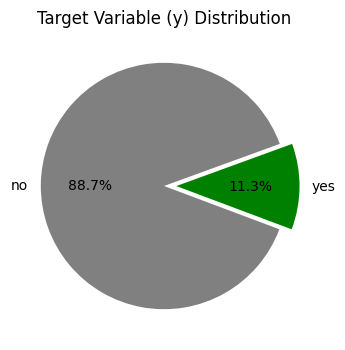

In [13]:
y = df_2_no_duration_pdays['y']
y_summary = pd.DataFrame({
    'Count': df_2_no_duration_pdays['y'].value_counts(),
    'Percentage (%)': (df_2_no_duration_pdays['y'].value_counts(normalize=True) * 100).round(2),
})

print(y_summary)
print('=' * 20)

plt.figure(figsize=(4, 4))
plt.pie(
    y_summary['Count'],
    labels=y_summary.index,
    startangle=20,
    autopct='%1.1f%%',
    colors=['grey', 'green'],
    explode=(0, 0.1),  # Slightly separates the minority class for visual pop
)
plt.title('Target Variable (y) Distribution')
plt.show()

Baseline acceptance rate across the dataset is `11.3%`

In [14]:
baseline_accept = round(y_summary['Percentage (%)'].min(), 2)
baseline_accept

11.27

In [15]:
# View all feature value counts with their corresponding outcome rates

cat_cols = list(df_2_no_duration_pdays.select_dtypes(include="object"))
cat_cols.remove("y") # remove the target variable

melted = df_2_no_duration_pdays.melt(
    id_vars="y",
    value_vars=cat_cols,
    var_name="Feature",
    value_name="Category",
)

ct_counts = pd.crosstab(
    index=[melted["Feature"], melted["Category"]], columns=melted["y"]
)[["no", "yes"]].rename(columns={"no": "count_no", "yes": "count_yes"})

# Compute normalized percentages
ct_pct = (
    pd.crosstab(
        index=[melted["Feature"], melted["Category"]],
        columns=melted["y"],
        normalize="index",
    )[["no", "yes"]]
    * 100
).round(2).rename(columns={"no": "pct_no", "yes": "pct_yes"})

summary_ct = pd.concat([ct_counts, ct_pct], axis=1)
summary_ct["total_count"] = summary_ct["count_no"] + summary_ct["count_yes"]

sorted_ct = (
    summary_ct[[
        "total_count",
        "count_no",
        "count_yes",
        "pct_no",
        "pct_yes",
    ]]
    .reset_index()
    .sort_values(by=["Feature", "pct_yes"], ascending=[True, False])
    .reset_index(drop=True)
)

print(sorted_ct.to_string())

y       Feature             Category  total_count  count_no  count_yes  pct_no  pct_yes
0       contact             cellular        26144     22291       3853   85.26    14.74
1       contact            telephone        15044     14257        787   94.77     5.23
2   day_of_week                  thu         8623      7578       1045   87.88    12.12
3   day_of_week                  tue         8090      7137        953   88.22    11.78
4   day_of_week                  wed         8134      7185        949   88.33    11.67
5   day_of_week                  fri         7827      6981        846   89.19    10.81
6   day_of_week                  mon         8514      7667        847   90.05     9.95
7       default                   no        32588     28391       4197   87.12    12.88
8       default              unknown         8597      8154        443   94.85     5.15
9       default                  yes            3         3          0  100.00     0.00
10    education           illite

Note the `default` column.
```
7       default                   no        32588     28391       4197   87.12    12.88
8       default              unknown         8597      8154        443   94.85     5.15
9       default                  yes            3         3          0  100.00     0.00
```

Conventional wisdom says that a person who defaults is pretty likely to _not_ have the money to seal away as part of a "term deposit" program. Our data does reflect this overwhelmingly with nobody who defaulted (`default` = `y`) opening a deposit.

Or does it? Looking closer, only 3 people have ever defaulted. Over 99.9% of the records are split between no and unknown. The `no` category converts near the baseline (12.88%), while `unknown` drops to 5.15%. Because the category of interest (`yes`) has virtually zero representation ($n=3$), this feature provides almost no useful predictive power regarding credit default behavior. Therefore, I am dropping this column.

In [16]:
df_3_no_default = df_2_no_duration_pdays.drop(['default'], axis=1)
df_3_no_default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41188 non-null  int64  
 1   job                 41188 non-null  object 
 2   marital             41188 non-null  object 
 3   education           41188 non-null  object 
 4   housing             41188 non-null  object 
 5   loan                41188 non-null  object 
 6   contact             41188 non-null  object 
 7   month               41188 non-null  object 
 8   day_of_week         41188 non-null  object 
 9   campaign            41188 non-null  int64  
 10  previous            41188 non-null  int64  
 11  poutcome            41188 non-null  object 
 12  emp.var.rate        41188 non-null  float64
 13  cons.price.idx      41188 non-null  float64
 14  cons.conf.idx       41188 non-null  float64
 15  euribor3m           41188 non-null  float64
 16  nr.e

In [17]:
sorted_ct2 = sorted_ct[sorted_ct['Feature'] != 'default'].reset_index(drop=True)
print(sorted_ct2['Feature'])

0         contact
1         contact
2     day_of_week
3     day_of_week
4     day_of_week
5     day_of_week
6     day_of_week
7       education
8       education
9       education
10      education
11      education
12      education
13      education
14      education
15        housing
16        housing
17        housing
18            job
19            job
20            job
21            job
22            job
23            job
24            job
25            job
26            job
27            job
28            job
29            job
30           loan
31           loan
32           loan
33        marital
34        marital
35        marital
36        marital
37          month
38          month
39          month
40          month
41          month
42          month
43          month
44          month
45          month
46          month
47       poutcome
48       poutcome
49       poutcome
Name: Feature, dtype: object


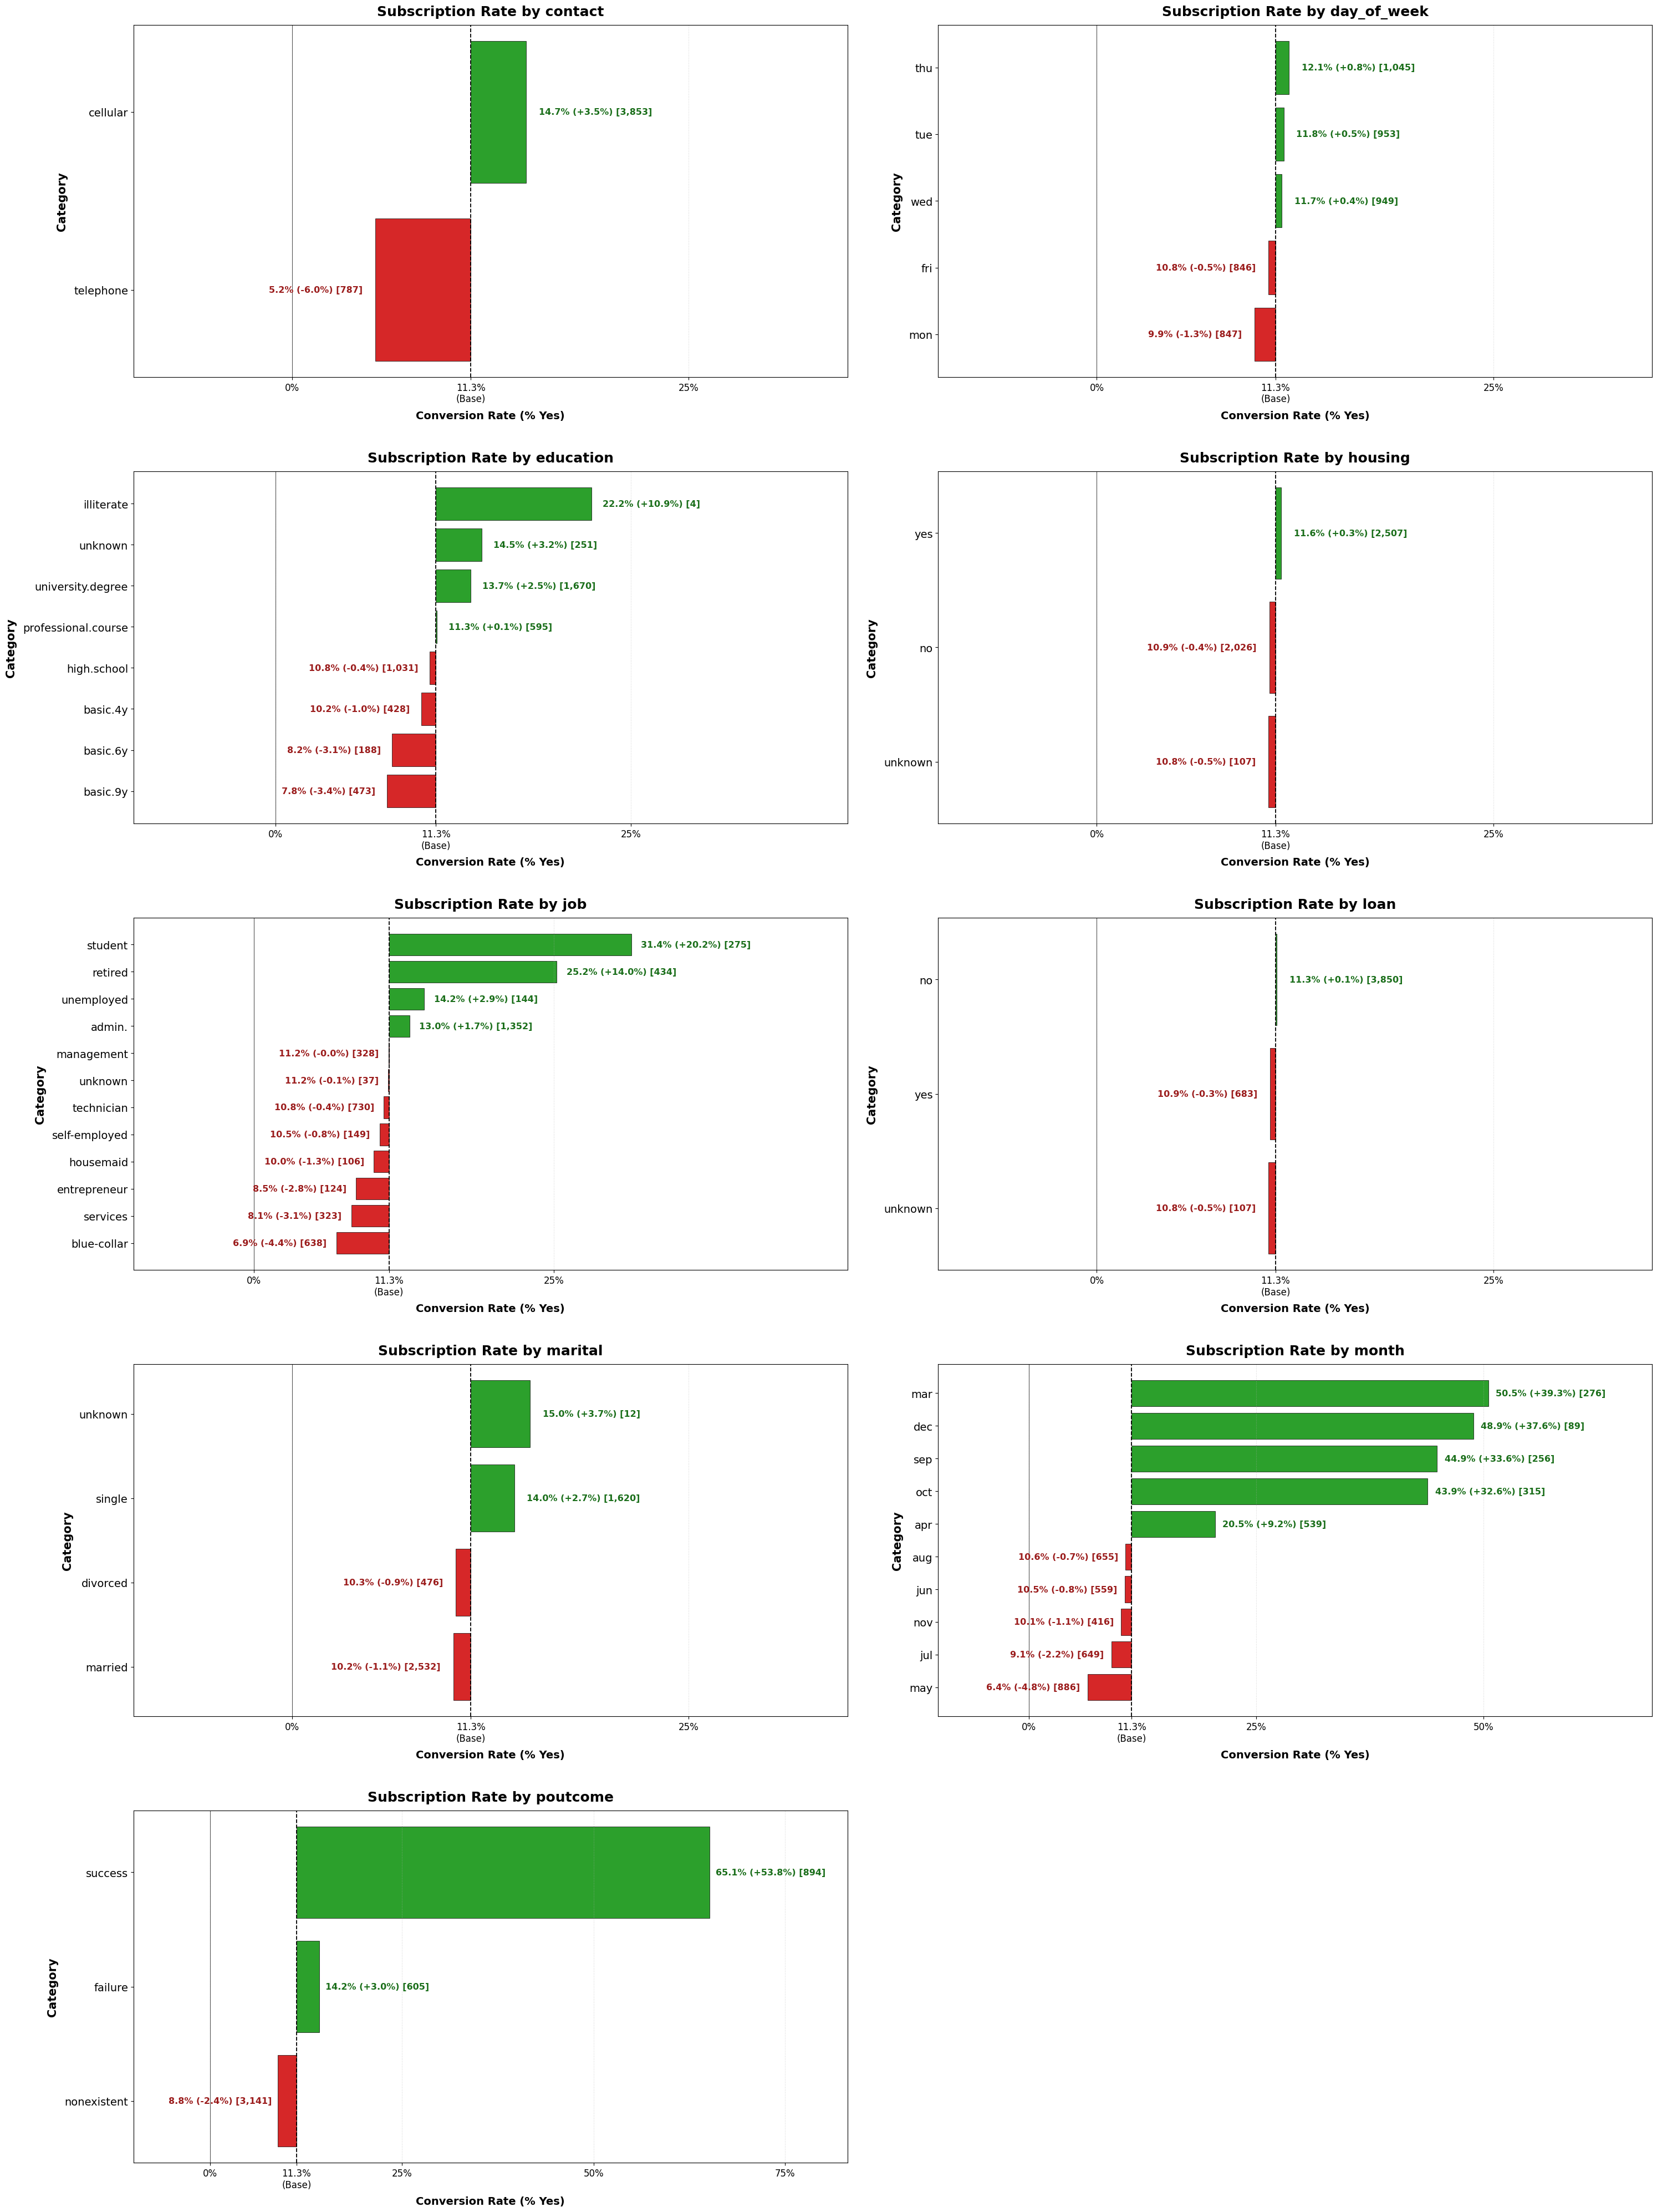

In [18]:
# Visualize the data as "acceptance driver above/below baseline"

# First find delta = baseline - actual
plot_df = sorted_ct2.copy()
plot_df["delta"] = plot_df["pct_yes"] - baseline_accept

# Setup Grid
features = plot_df["Feature"].unique()
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, figsize=(30, 8 * n_rows), sharex=False
)
axes_flat = axes.flatten()

# Standardized percentage ticks including the exact baseline
ticks = [0, baseline_accept, 25, 50, 75, 100]
tick_labels = [
    "0%",
    f"{baseline_accept:.1f}%\n(Base)",
    "25%",
    "50%",
    "75%",
    "100%",
]

for i, feat in enumerate(features):
  ax = axes_flat[i]
  subset = plot_df[plot_df["Feature"] == feat].sort_values(
      by="pct_yes", ascending=True
  )

  colors = ["#2ca02c" if d >= 0 else "#d62728" for d in subset["delta"]]

  # Diverging bars anchored at the baseline on a true 0-100% scale
  bars = ax.barh(
      subset["Category"],
      subset["delta"],  # Width = delta (negative width extends left)
      left=baseline_accept,  # All bars branch out from the baseline line
      color=colors,
      edgecolor="black",
      linewidth=0.5,
  )

  # Solid line for baseline, thin line for 0%
  ax.axvline(baseline_accept, color="black", linestyle="--", linewidth=1.3)
  ax.axvline(0, color="#555555", linestyle="-", linewidth=0.8)

  # Annotate each bar at its actual conversion rate position (pct_yes)
  for _, row in subset.iterrows():
    pct = row["pct_yes"]
    delta = row["delta"]
    cnt = int(row["count_yes"])
    sign = "+" if delta >= 0 else ""
    label_text = f"{pct:.1f}% ({sign}{delta:.1f}%) [{cnt:,}]"

    # Position text just outside the bar's tip
    if delta >= 0:
      ax.text(
          pct + 0.8,
          row["Category"],
          label_text,
          va="center",
          ha="left",
          fontsize=11.5,
          color="#1a6e1a",
          fontweight="bold",
      )
    else:
      ax.text(
          pct - 0.8,
          row["Category"],
          label_text,
          va="center",
          ha="right",
          fontsize=11.5,
          color="#9b1c1c",
          fontweight="bold",
      )

  # Axes, titles, and ticks
  ax.set_title(
      f"Subscription Rate by {feat}", fontsize=18, fontweight="bold", pad=12
  )
  ax.set_xlabel(
      "Conversion Rate (% Yes)", fontsize=14, fontweight="semibold", labelpad=8
  )
  ax.set_ylabel("Category", fontsize=15, fontweight="bold", labelpad=8)

  ax.set_xticks(ticks)
  ax.set_xticklabels(tick_labels)
  ax.tick_params(axis="y", labelsize=14)
  ax.tick_params(axis="x", labelsize=12)

  # Fixed clean span with breathing room for labels
  max_pct = subset["pct_yes"].max()
  right_bound = min(100, max(max_pct + 18, 35))
  ax.set_xlim(-10, right_bound)
  ax.grid(axis="x", linestyle=":", alpha=0.5)

# Clean up empty subplots
for j in range(len(features), len(axes_flat)):
  fig.delaxes(axes_flat[j])

plt.tight_layout(h_pad=4.0, w_pad=2.5)
plt.show()

#### Observations

* **Prior Outcome (`poutcome`):** Prior success is the single strongest positive driver at **65.1%** (+53.8%). Even past `failure` (**14.2%**) outperforms baseline, indicating any past engagement signals higher intent than `nonexistent` (**8.8%**).
* **Timing (`month`):** Low-volume campaign months show massive positive lift—`mar` (**50.5%**), `dec` (**48.9%**), `sep` (**44.9%**), and `oct` (**43.9%**). High-volume `may` drags conversion to **6.4%** (-4.8%).
  * Note the choice of month as well - this may indicate end of fiscal quarter contacts. Not sure if actionable right now, but interesting to note
* **Channel (`contact`):** `cellular` contacts convert at **14.7%** (+3.5%), while landline `telephone` outreach drops conversion to **5.2%** (-6.0%).
* **Occupation (`job`):** `student` (**31.4%**) and `retired` (**25.2%**) provide the highest positive conversion lift, whereas `blue-collar` workers show the strongest negative drag at **6.9%** (-4.4%).
* **Marital Status (`marital`):** `single` clients lead conversion at **14.0%** (+2.7%), while `married` (**10.2%**) and `divorced` (**10.3%**) sit below baseline.
* **Education (`education`):** `illiterate` nominally leads at **22.2%** but is an extreme outlier ($n=18$, 4 conversions); the primary volume driver is `university.degree` (**13.7%**), while all `basic` sub-tiers underperform (<**10.3%**).
* **Low-Variance Drivers:** `housing`, `loan`, and `day_of_week` show minimal deviation from the baseline (<**1.5%** delta across all categories).

Before looking at the continuous features now, I will permenantely convert the output variable to a binary classification rather the string-based `yes` or `no`.

In [51]:
df_3_no_default['y'] = (df_3_no_default['y'] == 'yes').astype(int)

In [52]:
cont_cols = sorted(list(df_3_no_default.select_dtypes(exclude="object")))
for col in cont_cols:
  min = df_3_no_default[col].min()
  max = df_3_no_default[col].max()
  print(f"Col<{col}> \"{bank_feature_descriptions[col]}\"\n Range [{min}, {max}]")

Col<age> "Age of the client"
 Range [17, 98]
Col<campaign> "Number of contacts performed during this campaign for this client"
 Range [1, 56]
Col<cons.conf.idx> "Consumer confidence index - monthly indicator"
 Range [-50.8, -26.9]
Col<cons.price.idx> "Consumer price index - monthly indicator"
 Range [92.201, 94.767]
Col<emp.var.rate> "Employment variation rate - quarterly indicator"
 Range [-3.4, 1.4]
Col<euribor3m> "Euribor 3 month rate - daily indicator"
 Range [0.634, 5.045]
Col<last_month_contact> "Was the client contacted in the last month? (27 days)"
 Range [0, 1]
Col<nr.employed> "Number of employees - quarterly indicator"
 Range [4963.6, 5228.1]
Col<previous> "Number of contacts performed before this campaign for this client"
 Range [0, 7]
Col<y> "Has the client subscribed a term deposit? (Target variable)"
 Range [0, 1]


In [55]:
corr_df = df_3_no_default[cont_cols].corr()
corr_df

,age,campaign,cons.conf.idx,cons.price.idx,emp.var.rate,euribor3m,last_month_contact,nr.employed,previous,y
age,1.000000,0.004594,0.129372,0.000857,-0.000371,0.010767,0.034292,-0.017725,0.024365,0.030399
campaign,0.004594,1.000000,-0.013733,0.127836,0.150754,0.135133,-0.052569,0.144095,-0.079141,-0.066357
cons.conf.idx,0.129372,-0.013733,1.000000,0.058986,0.196041,0.277686,0.091254,0.100513,-0.050936,0.054878
cons.price.idx,0.000857,0.127836,0.058986,1.000000,0.775334,0.688230,-0.078715,0.522034,-0.203130,-0.136211
emp.var.rate,-0.000371,0.150754,0.196041,0.775334,1.000000,0.972245,-0.270945,0.906970,-0.420489,-0.298334
euribor3m,0.010767,0.135133,0.277686,0.688230,0.972245,1.000000,-0.296920,0.945154,-0.454494,-0.307771
last_month_contact,0.034292,-0.052569,0.091254,-0.078715,-0.270945,-0.296920,1.000000,-0.372682,0.587462,0.324877
nr.employed,-0.017725,0.144095,0.100513,0.522034,0.906970,0.945154,-0.372682,1.000000,-0.501333,-0.354678
previous,0.024365,-0.079141,-0.050936,-0.203130,-0.420489,-0.454494,0.587462,-0.501333,1.000000,0.230181
y,0.030399,-0.066357,0.054878,-0.136211,-0.298334,-0.307771,0.324877,-0.354678,0.230181,1.000000


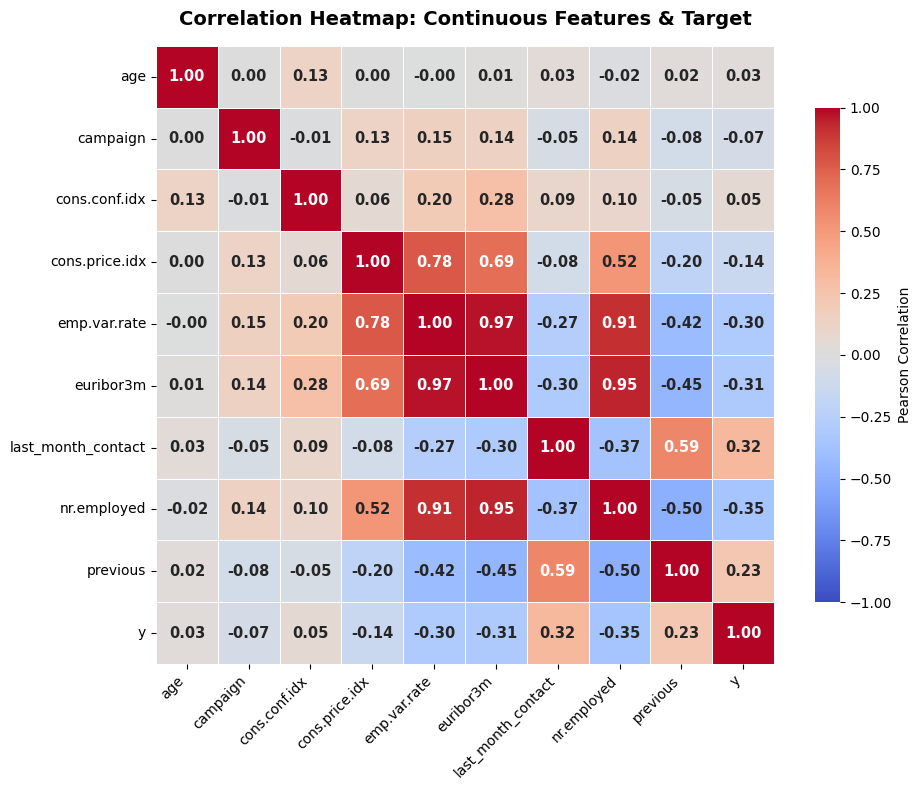

In [56]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
    annot_kws={"size": 10.5, "weight": "bold"},
)

plt.title(
    "Correlation Heatmap: Continuous Features & Target",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

#### Observations

* `euribor3m`, `emp.var.rate`, and `nr.employed` exhibit extreme pairwise collinearity ($r = 0.91$ to $0.97$), capturing the same underlying macro environment and causing unstable linear model coefficients.
  * at the same time, these same macro indicators show the strongest negative linear relationships with subscription: `nr.employed` ($r = -0.35$), `euribor3m` ($r = -0.31$), and `emp.var.rate` ($r = -0.30$).

* `last_month_contact` ($r = 0.32$) and `previous` ($r = 0.23$) are the strongest positive continuous predictors, **confirming** that prior campaign exposure significantly boosts conversion likelihood
* Low Linear Correlation in `age` ($r = 0.03$) makes sense when we consider that the stronger occupation drivers were `student` and `retired`
* `campaign` has a low correlation - this may imply that repeatd contacts has greatly diminishing returns

Based on thsi data, I am opting to drop `emp.var.rate` and retaining `euribor3m`. Based on online documenation, 3-month Euribor rate is a standard interbank benchmark, direclty informing bank term deposits. They have similar negative relationships with the target variable and are highly correlated ``0.97`.

In [57]:
df_4_no_empvarrate = df_3_no_default.drop(['emp.var.rate'], axis=1)
df_4_no_empvarrate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41188 non-null  int64  
 1   job                 41188 non-null  object 
 2   marital             41188 non-null  object 
 3   education           41188 non-null  object 
 4   housing             41188 non-null  object 
 5   loan                41188 non-null  object 
 6   contact             41188 non-null  object 
 7   month               41188 non-null  object 
 8   day_of_week         41188 non-null  object 
 9   campaign            41188 non-null  int64  
 10  previous            41188 non-null  int64  
 11  poutcome            41188 non-null  object 
 12  cons.price.idx      41188 non-null  float64
 13  cons.conf.idx       41188 non-null  float64
 14  euribor3m           41188 non-null  float64
 15  nr.employed         41188 non-null  float64
 16  y   

In [58]:
# save cleaned df
parquet_output_path = create_parquet_path("df_4_no_empvarrate")
os.makedirs(os.path.dirname(parquet_output_path), exist_ok=True)

In [59]:
df_4_no_empvarrate.to_parquet(parquet_output_path, index=False)
print(f"Saved cleaned dataset to: {parquet_output_path}")

Saved cleaned dataset to: drive/MyDrive/all_data/17/data/output/dataframes/df_4_no_empvarrate.parquet


### Problem 4: Business Objective

Following exploratory data analysis, I have distilled my project's goal which is:

>*To predict whether a bank client will subscribe to a term deposit based on demographic attributes, economic indicators, and historical campaign touchpoints.*

I will treat the solution for this problem as a binary classification task where the target variable y represents subscription (1 for yes, 0 for no).

From a business perspective, accurately identifying high-probability clients allows banks to prioritize high-yield leads, reduce wasted outreach calls, and maximize overall campaign conversion efficiency.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [ ]:
# Uncomment to load back the DF
# parquet_input_path = create_parquet_path("df_4_no_empvarrate")

# print(f"Loaded dataset from: {dparquet_input_path}")
# print(f"Shape: {df_4_no_empvarrate.shape}")
# df_4_no_empvarrate.info()

In [60]:
df_cleaned = df_4_no_empvarrate.copy()
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41188 non-null  int64  
 1   job                 41188 non-null  object 
 2   marital             41188 non-null  object 
 3   education           41188 non-null  object 
 4   housing             41188 non-null  object 
 5   loan                41188 non-null  object 
 6   contact             41188 non-null  object 
 7   month               41188 non-null  object 
 8   day_of_week         41188 non-null  object 
 9   campaign            41188 non-null  int64  
 10  previous            41188 non-null  int64  
 11  poutcome            41188 non-null  object 
 12  cons.price.idx      41188 non-null  float64
 13  cons.conf.idx       41188 non-null  float64
 14  euribor3m           41188 non-null  float64
 15  nr.employed         41188 non-null  float64
 16  y   

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41188 non-null  int64  
 1   job                 41188 non-null  object 
 2   marital             41188 non-null  object 
 3   education           41188 non-null  object 
 4   default             41188 non-null  object 
 5   housing             41188 non-null  object 
 6   loan                41188 non-null  object 
 7   contact             41188 non-null  object 
 8   month               41188 non-null  object 
 9   day_of_week         41188 non-null  object 
 10  duration            41188 non-null  int64  
 11  campaign            41188 non-null  int64  
 12  pdays               41188 non-null  int64  
 13  previous            41188 non-null  int64  
 14  poutcome            41188 non-null  object 
 15  emp.var.rate        41188 non-null  float64
 16  cons

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

### Problem 9: Score the Model

What is the accuracy of your model?

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions